# ECG5000 Anomaly Detection
**Name:** Sepehr Barekati   
**Student ID:** 404422029   
**Instructor:** Dr. Farahani 

---

## 1. Overview

A reproducible study of reconstruction-based anomaly detection on the
UCR **ECG5000** heartbeat dataset. We compare a **Conv1D Autoencoder**
against an **LSTM Autoencoder**, benchmark them against **One-Class SVM**
and **Isolation Forest**, systematically compare four **threshold-selection**
strategies, and perform a **latent-dimension capacity ablation** that
illustrates the reconstruction paradox.

All numbers, tables and figures in the accompanying LaTeX report are produced by
this notebook — nothing is hand-crafted.

## 2. Imports

In [1]:
import os, json, time, random, warnings
from pathlib import Path

import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve)
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
%matplotlib inline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
print("torch:", torch.__version__, "  CUDA:", torch.cuda.is_available())

torch: 2.13.0+cu130   CUDA: False


## 3. Reproducibility Configuration

All non-determinism-controlling parameters are collected here.  Any
change to hyperparameters happens **only in this cell**.

In [2]:
CONFIG = {
    "RANDOM_SEED": 42,
    "DATA_DIR": "data",
    "FIG_DIR":  "figures",
    "RES_DIR":  "results",
    "VAL_SIZE": 0.20,
    "LEARNING_RATE": 1e-3,
    "BATCH_SIZE": 32,
    "MAX_EPOCHS": 100,
    "EARLY_STOPPING_PATIENCE": 12,
    "LATENT_DIM": 16,
    "DROPOUT": 0.10,
    "WEIGHT_DECAY": 1e-5,
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu",
}
Path(CONFIG["FIG_DIR"]).mkdir(exist_ok=True, parents=True)
Path(CONFIG["RES_DIR"]).mkdir(exist_ok=True, parents=True)

def set_seed(seed=CONFIG["RANDOM_SEED"]):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()
DEVICE = torch.device(CONFIG["DEVICE"])
DEVICE

device(type='cpu')

## 4. Dataset Download & Load

The ECG5000 dataset is fetched programmatically from the UCR/UEA Time
Series Classification archive.  The archive already ships an official
train/test split, which we adopt.

In [3]:
import urllib.request, zipfile, io
URL = "https://www.timeseriesclassification.com/aeon-toolkit/ECG5000.zip"
os.makedirs(CONFIG["DATA_DIR"], exist_ok=True)
if not os.path.exists(f"{CONFIG['DATA_DIR']}/ECG5000_TRAIN.txt"):
    with urllib.request.urlopen(URL) as r:
        with zipfile.ZipFile(io.BytesIO(r.read())) as z:
            z.extractall(CONFIG["DATA_DIR"])
sorted(os.listdir(CONFIG["DATA_DIR"]))

['ECG5000.txt',
 'ECG5000_TEST.arff',
 'ECG5000_TEST.ts',
 'ECG5000_TEST.txt',
 'ECG5000_TRAIN.arff',
 'ECG5000_TRAIN.ts',
 'ECG5000_TRAIN.txt']

In [4]:
def load_ucr_txt(path):
    arr = np.loadtxt(path)
    return arr[:, 1:].astype(np.float32), arr[:, 0].astype(int)

X_train_full, y_train_full = load_ucr_txt(f"{CONFIG['DATA_DIR']}/ECG5000_TRAIN.txt")
X_test,       y_test       = load_ucr_txt(f"{CONFIG['DATA_DIR']}/ECG5000_TEST.txt")
X_train_full.shape, X_test.shape

((500, 140), (4500, 140))

## 5. Dataset Inspection

Programmatically verify shapes, labels, missing values, duplicates and value ranges.

In [5]:
inspect_rows = []
for name, X, y in [("TRAIN", X_train_full, y_train_full), ("TEST", X_test, y_test)]:
    v, c = np.unique(y, return_counts=True)
    inspect_rows.append({
        "split": name, "n_rows": X.shape[0], "n_features": X.shape[1],
        "n_classes": len(v), "n_missing": int(np.isnan(X).sum()),
        "n_duplicates": int(pd.DataFrame(X).duplicated().sum()),
        "value_min": float(X.min()), "value_max": float(X.max()),
    })
inspect_df = pd.DataFrame(inspect_rows)
display(inspect_df)
inspect_df

,split,n_rows,n_features,n_classes,n_missing,n_duplicates,value_min,value_max
0,TRAIN,500,140,5,0,0,-5.797645,4.058127
1,TEST,4500,140,5,0,0,-7.090374,7.402103


,split,n_rows,n_features,n_classes,n_missing,n_duplicates,value_min,value_max
0,TRAIN,500,140,5,0,0,-5.797645,4.058127
1,TEST,4500,140,5,0,0,-7.090374,7.402103


## 6. Exploratory Data Analysis

ECG5000 contains 5 heartbeat classes.  Class 1 corresponds to normal
heartbeats (the majority); classes 2-5 correspond to different types of
abnormal beats and are extremely imbalanced.

In [6]:
dist_train = pd.Series(y_train_full).value_counts().sort_index()
dist_test  = pd.Series(y_test).value_counts().sort_index()
class_dist_df = pd.DataFrame({"train": dist_train, "test": dist_test})
class_dist_df.index.name = "class"
display(class_dist_df)
class_dist_df

,train,test
class,,
1,292,2627
2,177,1590
3,10,86
4,19,175
5,2,22


,train,test
class,,
1,292,2627
2,177,1590
3,10,86
4,19,175
5,2,22


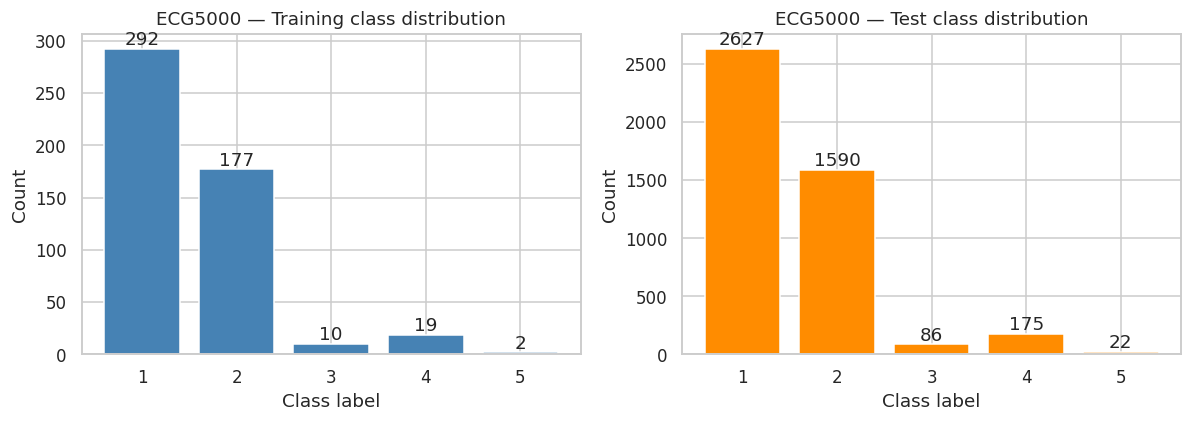

In [7]:
# Figure 1 — class distribution
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
vals_tr, cnts_tr = np.unique(y_train_full, return_counts=True)
vals_te, cnts_te = np.unique(y_test,       return_counts=True)
ax[0].bar([str(v) for v in vals_tr], cnts_tr, color="steelblue")
ax[0].set_title("ECG5000 — Training class distribution")
ax[0].set_xlabel("Class label"); ax[0].set_ylabel("Count")
for x, c in zip(vals_tr, cnts_tr): ax[0].text(str(x), c, str(c), ha="center", va="bottom")
ax[1].bar([str(v) for v in vals_te], cnts_te, color="darkorange")
ax[1].set_title("ECG5000 — Test class distribution")
ax[1].set_xlabel("Class label"); ax[1].set_ylabel("Count")
for x, c in zip(vals_te, cnts_te): ax[1].text(str(x), c, str(c), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{CONFIG['FIG_DIR']}/class_distribution.png")
plt.show()

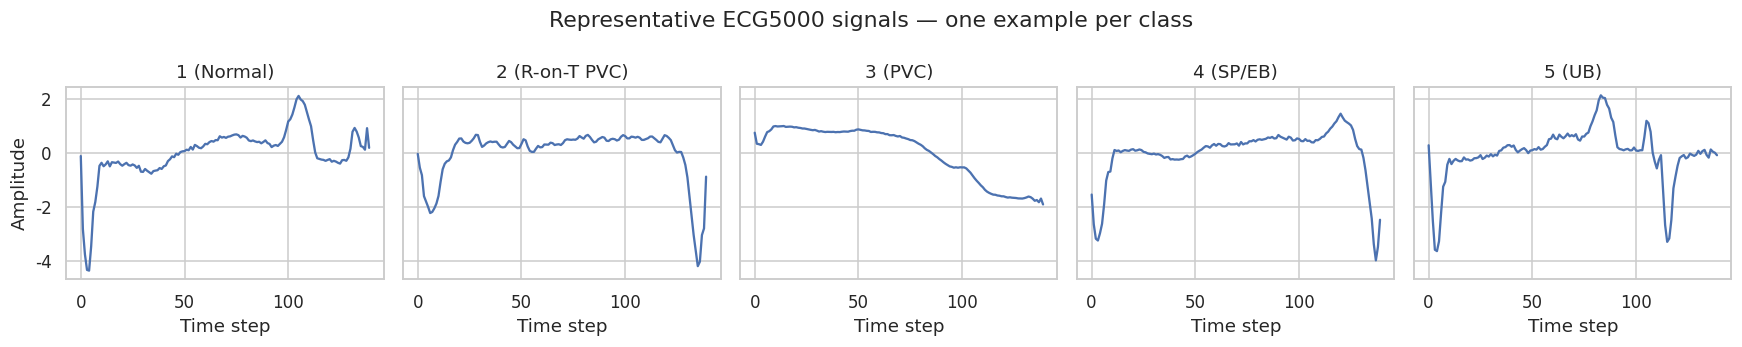

In [8]:
# Figure 2 — one example per class
class_names = {1:"1 (Normal)",2:"2 (R-on-T PVC)",3:"3 (PVC)",4:"4 (SP/EB)",5:"5 (UB)"}
fig, ax = plt.subplots(1, 5, figsize=(16, 3.2), sharey=True)
for i, cls in enumerate([1, 2, 3, 4, 5]):
    idx = np.where(y_train_full == cls)[0][0]
    ax[i].plot(X_train_full[idx], color="C0")
    ax[i].set_title(class_names.get(cls, str(cls)))
    ax[i].set_xlabel("Time step")
ax[0].set_ylabel("Amplitude")
plt.suptitle("Representative ECG5000 signals — one example per class")
plt.tight_layout()
plt.savefig(f"{CONFIG['FIG_DIR']}/example_signals.png")
plt.show()

## 7. Label mapping

Binary anomaly target while preserving original class labels for error analysis.

```
Normal   = 0   (original class 1)
Abnormal = 1   (original classes 2, 3, 4, 5)
```

In [9]:
NORMAL_LABEL = 1
to_binary = lambda y: (y != NORMAL_LABEL).astype(int)
y_train_full_bin = to_binary(y_train_full)
y_test_bin       = to_binary(y_test)
label_map_df = pd.DataFrame([
    {"split": "train", "normal": int((y_train_full_bin==0).sum()),
     "abnormal": int((y_train_full_bin==1).sum())},
    {"split": "test",  "normal": int((y_test_bin==0).sum()),
     "abnormal": int((y_test_bin==1).sum())},
])
display(label_map_df)
label_map_df

,split,normal,abnormal
0,train,292,208
1,test,2627,1873


,split,normal,abnormal
0,train,292,208
1,test,2627,1873


## 8. Train / Validation / Test split

Stratified 20% validation carved from the training portion, seed 42.
Autoencoders will be trained on **normal training rows only**.

In [10]:
X_tr, X_val, y_tr, y_val, y_tr_orig, y_val_orig = train_test_split(
    X_train_full, y_train_full_bin, y_train_full,
    test_size=CONFIG["VAL_SIZE"], stratify=y_train_full_bin,
    random_state=CONFIG["RANDOM_SEED"])
mask_normal_tr = (y_tr == 0)
X_tr_normal = X_tr[mask_normal_tr]
split_df = pd.DataFrame([
    {"partition": "train (full)", "rows": len(X_tr),
     "normal": int((y_tr==0).sum()), "abnormal": int((y_tr==1).sum())},
    {"partition": "train (normal-only, used for AE)", "rows": len(X_tr_normal),
     "normal": len(X_tr_normal), "abnormal": 0},
    {"partition": "validation", "rows": len(X_val),
     "normal": int((y_val==0).sum()), "abnormal": int((y_val==1).sum())},
    {"partition": "test", "rows": len(X_test),
     "normal": int((y_test_bin==0).sum()), "abnormal": int((y_test_bin==1).sum())},
])
display(split_df)
split_df

,partition,rows,normal,abnormal
0,train (full),400,234,166
1,"train (normal-only, used for AE)",234,234,0
2,validation,100,58,42
3,test,4500,2627,1873


,partition,rows,normal,abnormal
0,train (full),400,234,166
1,"train (normal-only, used for AE)",234,234,0
2,validation,100,58,42
3,test,4500,2627,1873


## 9. Preprocessing — z-score on normal training rows only

$$x_{\text{scaled}} = \frac{x - \mu_{\text{train,normal}}}{\sigma_{\text{train,normal}}}$$

In [11]:
mu = X_tr_normal.mean().astype(np.float32)
sd = X_tr_normal.std().astype(np.float32)
scale = lambda X: ((X - mu) / sd).astype(np.float32)
X_tr_n, X_val_s, X_test_s = scale(X_tr_normal), scale(X_val), scale(X_test)
scaling_df = pd.DataFrame([{"mu": float(mu), "sd": float(sd),
                             "fit_on_rows": len(X_tr_normal)}])
display(scaling_df)
scaling_df

,mu,sd,fit_on_rows
0,1.164438e-10,0.996422,234


,mu,sd,fit_on_rows
0,1.164438e-10,0.996422,234


## 10. DataLoader construction

In [12]:
def to_tensor(X): return torch.from_numpy(X).unsqueeze(1)
train_loader = DataLoader(TensorDataset(to_tensor(X_tr_n)),
    batch_size=CONFIG["BATCH_SIZE"], shuffle=True,
    generator=torch.Generator().manual_seed(CONFIG["RANDOM_SEED"]))
mask_normal_val = (y_val == 0)
val_loader_normal = DataLoader(TensorDataset(to_tensor(X_val_s[mask_normal_val])),
    batch_size=CONFIG["BATCH_SIZE"], shuffle=False)
print("train samples:", len(train_loader.dataset),
      "  val samples (normal):", len(val_loader_normal.dataset))

train samples: 234   val samples (normal): 58


## 11. Conv1D Autoencoder

Symmetric encoder-decoder with three convolutional stages, MaxPool downsampling and linear upsampling.

In [13]:
class Conv1DAutoencoder(nn.Module):
    def __init__(self, seq_len=140, latent_dim=16, dropout=0.10):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(dropout),
            nn.Conv1d(16, 32, 5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(dropout),
            nn.Conv1d(32, 64, 3, padding=1), nn.ReLU(),
        )
        self.flat   = nn.Flatten()
        self.fc_enc = nn.Linear(64*35, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 64*35)
        self.dec = nn.Sequential(
            nn.Conv1d(64, 32, 3, padding=1), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Dropout(dropout),
            nn.Conv1d(32, 16, 5, padding=2), nn.ReLU(),
            nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
            nn.Dropout(dropout),
            nn.Conv1d(16, 1, 7, padding=3),
        )
    def forward(self, x):
        z = self.fc_enc(self.flat(self.enc(x)))
        h = self.fc_dec(z).view(-1, 64, 35)
        return self.dec(h)

## 12. Model summary

In [14]:
def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
set_seed()
conv_ae = Conv1DAutoencoder(latent_dim=CONFIG["LATENT_DIM"], dropout=CONFIG["DROPOUT"])
n_conv = count_params(conv_ae)
conv_summary_df = pd.DataFrame([{"model": "Conv1D AE", "latent_dim": CONFIG["LATENT_DIM"],
                                  "dropout": CONFIG["DROPOUT"], "params": n_conv}])
display(conv_summary_df)
conv_summary_df

,model,latent_dim,dropout,params
0,Conv1D AE,16,0.1,91729


,model,latent_dim,dropout,params
0,Conv1D AE,16,0.1,91729


## 13. Training

Adam + weight decay, MSE loss, early stopping on normal-only validation.

In [15]:
def train_ae(model, tr_loader, va_loader, tag, lr=None, epochs=None, patience=None):
    lr       = lr       or CONFIG["LEARNING_RATE"]
    epochs   = epochs   or CONFIG["MAX_EPOCHS"]
    patience = patience or CONFIG["EARLY_STOPPING_PATIENCE"]
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr,
                           weight_decay=CONFIG["WEIGHT_DECAY"])
    crit = nn.MSELoss()
    best_val, best_state, best_ep, wait = float("inf"), None, 0, 0
    hist = {"train": [], "val": []}; t0 = time.time()
    for epoch in range(1, epochs+1):
        model.train(); tr = []
        for (xb,) in tr_loader:
            xb = xb.to(DEVICE); opt.zero_grad()
            loss = crit(model(xb), xb); loss.backward(); opt.step()
            tr.append(loss.item())
        model.eval(); vl = []
        with torch.no_grad():
            for (xb,) in va_loader:
                xb = xb.to(DEVICE)
                vl.append(crit(model(xb), xb).item())
        tr_mean, vl_mean = float(np.mean(tr)), float(np.mean(vl))
        hist["train"].append(tr_mean); hist["val"].append(vl_mean)
        if vl_mean < best_val - 1e-6:
            best_val, best_ep, wait = vl_mean, epoch, 0
            best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}
        else:
            wait += 1
        if wait >= patience: break
    model.load_state_dict(best_state)
    return model, hist, best_ep, time.time()-t0

conv_ae, conv_hist, conv_best_ep, conv_dur = train_ae(
    conv_ae, train_loader, val_loader_normal, tag="conv")
print(f"trained in {conv_dur:.1f}s   best_epoch={conv_best_ep}")

trained in 17.6s   best_epoch=99


## 14. Training curves

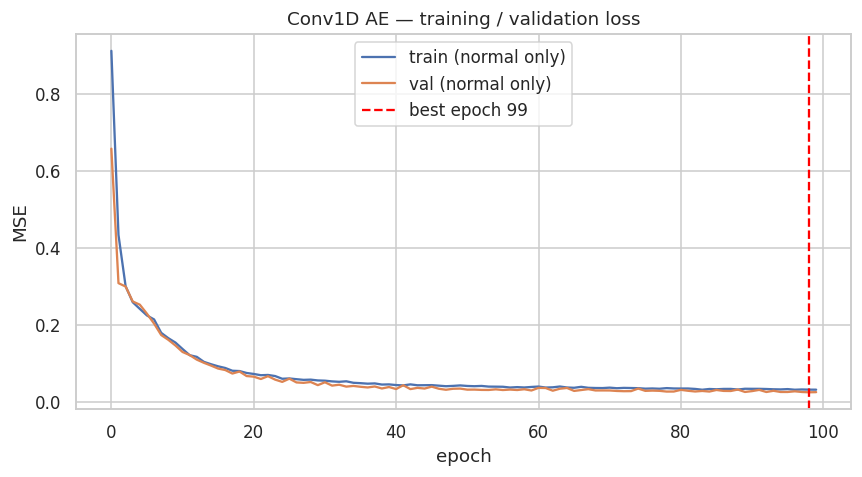

In [16]:
plt.figure(figsize=(8,4.5))
plt.plot(conv_hist["train"], label="train (normal only)")
plt.plot(conv_hist["val"],   label="val (normal only)")
plt.axvline(conv_best_ep-1, ls="--", c="red", label=f"best epoch {conv_best_ep}")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend()
plt.title("Conv1D AE — training / validation loss"); plt.tight_layout()
plt.savefig(f"{CONFIG['FIG_DIR']}/training_history.png")
plt.show()

## 15. Reconstruction & anomaly scores

$$s_i = \text{MSE}(x_i, \hat x_i) = \frac{1}{T}\sum_{t=1}^{T}(x_{i,t}-\hat x_{i,t})^2$$

In [17]:
def reconstruction_error(model, X):
    model.eval()
    with torch.no_grad():
        x = to_tensor(X).to(DEVICE); r = model(x)
        return ((x-r)**2).mean(dim=(1,2)).cpu().numpy()

conv_err_val  = reconstruction_error(conv_ae, X_val_s)
conv_err_test = reconstruction_error(conv_ae, X_test_s)

err_summary_df = pd.DataFrame([
    {"split": "val  (normal)",   "n": int((y_val==0).sum()),
     "mean_err": float(conv_err_val[y_val==0].mean()),
     "std_err":  float(conv_err_val[y_val==0].std())},
    {"split": "val  (abnormal)", "n": int((y_val==1).sum()),
     "mean_err": float(conv_err_val[y_val==1].mean()),
     "std_err":  float(conv_err_val[y_val==1].std())},
    {"split": "test (normal)",   "n": int((y_test_bin==0).sum()),
     "mean_err": float(conv_err_test[y_test_bin==0].mean()),
     "std_err":  float(conv_err_test[y_test_bin==0].std())},
    {"split": "test (abnormal)", "n": int((y_test_bin==1).sum()),
     "mean_err": float(conv_err_test[y_test_bin==1].mean()),
     "std_err":  float(conv_err_test[y_test_bin==1].std())},
])
display(err_summary_df)
err_summary_df

,split,n,mean_err,std_err
0,val (normal),58,0.024024,0.018892
1,val (abnormal),42,0.209286,0.071935
2,test (normal),2627,0.025598,0.040967
3,test (abnormal),1873,0.227429,0.140352


,split,n,mean_err,std_err
0,val (normal),58,0.024024,0.018892
1,val (abnormal),42,0.209286,0.071935
2,test (normal),2627,0.025598,0.040967
3,test (abnormal),1873,0.227429,0.140352


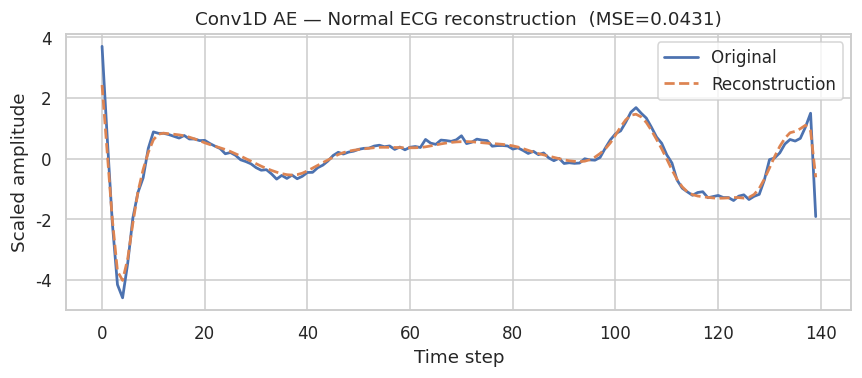

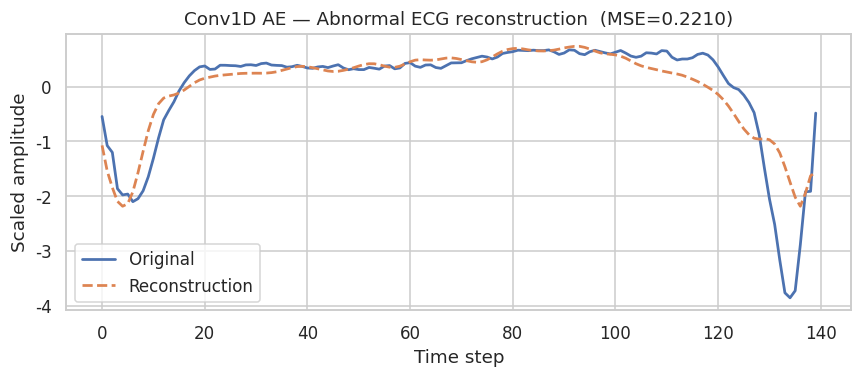

In [18]:
# Reconstruction examples — one normal, one abnormal
def plot_reconstruction(model, X_np, y_bin_np, is_normal, path, title):
    idx = np.where(y_bin_np == (0 if is_normal else 1))[0][0]
    x_original = X_np[idx]
    with torch.no_grad():
        r = model(to_tensor(x_original[None, :]).to(DEVICE)).cpu().numpy().squeeze()
    plt.figure(figsize=(8, 3.6))
    plt.plot(x_original, label="Original", linewidth=1.8)
    plt.plot(r, label="Reconstruction", linewidth=1.8, linestyle="--")
    err = float(np.mean((x_original - r) ** 2))
    plt.title(f"{title}  (MSE={err:.4f})")
    plt.xlabel("Time step"); plt.ylabel("Scaled amplitude"); plt.legend()
    plt.tight_layout(); plt.savefig(path); plt.show()

plot_reconstruction(conv_ae, X_test_s, y_test_bin, True,
    f"{CONFIG['FIG_DIR']}/normal_reconstruction.png",
    "Conv1D AE — Normal ECG reconstruction")
plot_reconstruction(conv_ae, X_test_s, y_test_bin, False,
    f"{CONFIG['FIG_DIR']}/abnormal_reconstruction.png",
    "Conv1D AE — Abnormal ECG reconstruction")

## 16. Threshold-selection — four methods

1. **Percentile** on normal validation errors.
2. **Mean + k · std** on normal validation errors.
3. **Median + k · MAD** (robust).
4. **Validation F1 argmax** using validation labels.

In [19]:
def eval_at(t, err, y):
    p = (err > t).astype(int)
    return {"precision": precision_score(y,p,zero_division=0),
            "recall":    recall_score(y,p,zero_division=0),
            "f1":        f1_score(y,p,zero_division=0)}

normal_val_err = conv_err_val[y_val == 0]
rows = []
for p in [90, 92.5, 95, 97.5, 99]:
    t = float(np.percentile(normal_val_err, p))
    rows.append({"method":"percentile","param":f"p={p}","threshold":t, **eval_at(t, conv_err_val, y_val)})
mu_n, sd_n = normal_val_err.mean(), normal_val_err.std()
for k in [1.0,1.5,2.0,2.5,3.0]:
    t = float(mu_n + k*sd_n)
    rows.append({"method":"mean+k*std","param":f"k={k}","threshold":t, **eval_at(t, conv_err_val, y_val)})
med = np.median(normal_val_err); mad = np.median(np.abs(normal_val_err-med))
for k in [1.0,2.0,3.0,4.0,5.0]:
    t = float(med + k*mad)
    rows.append({"method":"median+k*mad","param":f"k={k}","threshold":t, **eval_at(t, conv_err_val, y_val)})
prec, rec, thr = precision_recall_curve(y_val, conv_err_val)
f1c = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-12)
t_star = float(thr[int(np.nanargmax(f1c))])
rows.append({"method":"valF1-optimal","param":"argmax(F1)","threshold":t_star, **eval_at(t_star, conv_err_val, y_val)})

thr_df = pd.DataFrame(rows)
thr_df.to_csv(f"{CONFIG['RES_DIR']}/threshold_results.csv", index=False)
display(thr_df)
thr_df

,method,param,threshold,precision,recall,f1
0,percentile,p=90,0.035066,0.875000,1.000000,0.933333
1,percentile,p=92.5,0.042815,0.893617,1.000000,0.943820
2,percentile,p=95,0.058254,0.931818,0.976190,0.953488
3,percentile,p=97.5,0.090705,0.952381,0.952381,0.952381
4,percentile,p=99,0.098413,0.975610,0.952381,0.963855
5,mean+k*std,k=1.0,0.042915,0.893617,1.000000,0.943820
6,mean+k*std,k=1.5,0.052361,0.913043,1.000000,0.954545
7,mean+k*std,k=2.0,0.061807,0.931818,0.976190,0.953488
8,mean+k*std,k=2.5,0.071253,0.930233,0.952381,0.941176
9,mean+k*std,k=3.0,0.080699,0.930233,0.952381,0.941176


,method,param,threshold,precision,recall,f1
0,percentile,p=90,0.035066,0.875000,1.000000,0.933333
1,percentile,p=92.5,0.042815,0.893617,1.000000,0.943820
2,percentile,p=95,0.058254,0.931818,0.976190,0.953488
3,percentile,p=97.5,0.090705,0.952381,0.952381,0.952381
4,percentile,p=99,0.098413,0.975610,0.952381,0.963855
5,mean+k*std,k=1.0,0.042915,0.893617,1.000000,0.943820
6,mean+k*std,k=1.5,0.052361,0.913043,1.000000,0.954545
7,mean+k*std,k=2.0,0.061807,0.931818,0.976190,0.953488
8,mean+k*std,k=2.5,0.071253,0.930233,0.952381,0.941176
9,mean+k*std,k=3.0,0.080699,0.930233,0.952381,0.941176


## 17. Freezing the final threshold

The validation-F1-optimal method wins on validation → **frozen** for the test set.

In [20]:
FINAL_THRESHOLD = t_star
frozen_df = pd.DataFrame([{"model":"Conv1D AE", "method":"valF1-optimal",
                            "final_threshold": FINAL_THRESHOLD}])
display(frozen_df)
frozen_df

,model,method,final_threshold
0,Conv1D AE,valF1-optimal,0.111526


,model,method,final_threshold
0,Conv1D AE,valF1-optimal,0.111526


## 18. LSTM Autoencoder — original contribution

Sequence-to-sequence LSTM AE trained under the same protocol as the Conv1D AE.

In [21]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len=140, latent_dim=16, hidden=32, dropout=0.10):
        super().__init__()
        self.seq_len, self.latent_dim = seq_len, latent_dim
        self.enc = nn.LSTM(1, hidden, batch_first=True)
        self.enc_to_z = nn.Linear(hidden, latent_dim)
        self.z_to_dec = nn.Linear(latent_dim, hidden)
        self.dec = nn.LSTM(hidden, hidden, batch_first=True)
        self.out = nn.Linear(hidden, 1); self.drop = nn.Dropout(dropout)
    def forward(self, x):
        xt = x.transpose(1,2)
        _, (h,_) = self.enc(xt)
        z = self.enc_to_z(self.drop(h[-1]))
        dec_in = self.z_to_dec(z).unsqueeze(1).repeat(1, self.seq_len, 1)
        d,_ = self.dec(dec_in)
        return self.out(self.drop(d)).transpose(1,2)

set_seed()
lstm_ae = LSTMAutoencoder(latent_dim=CONFIG["LATENT_DIM"], hidden=32, dropout=CONFIG["DROPOUT"])
n_lstm = count_params(lstm_ae)
lstm_ae, lstm_hist, lstm_best_ep, lstm_dur = train_ae(
    lstm_ae, train_loader, val_loader_normal, tag="lstm")
lstm_summary_df = pd.DataFrame([{"model":"LSTM AE","latent_dim":CONFIG["LATENT_DIM"],
                                  "hidden":32,"dropout":CONFIG["DROPOUT"],
                                  "params":n_lstm,"best_epoch":lstm_best_ep,
                                  "train_time_s":round(lstm_dur,2)}])
display(lstm_summary_df)
lstm_summary_df

,model,latent_dim,hidden,dropout,params,best_epoch,train_time_s
0,LSTM AE,16,32,0.1,14033,75,9.94


,model,latent_dim,hidden,dropout,params,best_epoch,train_time_s
0,LSTM AE,16,32,0.1,14033,75,9.94


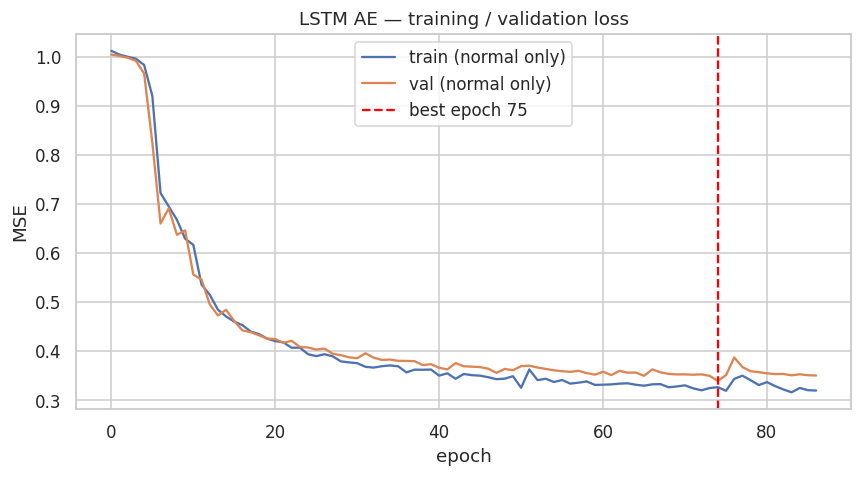

In [22]:
# LSTM training curves
plt.figure(figsize=(8,4.5))
plt.plot(lstm_hist["train"], label="train (normal only)")
plt.plot(lstm_hist["val"],   label="val (normal only)")
plt.axvline(lstm_best_ep-1, ls="--", c="red", label=f"best epoch {lstm_best_ep}")
plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend()
plt.title("LSTM AE — training / validation loss"); plt.tight_layout()
plt.savefig(f"{CONFIG['FIG_DIR']}/lstm_training_history.png")
plt.show()

In [23]:
lstm_err_val  = reconstruction_error(lstm_ae, X_val_s)
lstm_err_test = reconstruction_error(lstm_ae, X_test_s)
prec, rec, thr = precision_recall_curve(y_val, lstm_err_val)
f1l = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-12)
LSTM_THRESHOLD = float(thr[int(np.nanargmax(f1l))])
lstm_thr_df = pd.DataFrame([{"model":"LSTM AE","final_threshold":LSTM_THRESHOLD}])
display(lstm_thr_df)
lstm_thr_df

,model,final_threshold
0,LSTM AE,0.550786


,model,final_threshold
0,LSTM AE,0.550786


## 19. Conv1D vs LSTM — final metrics

In [24]:
def full_metrics(y, s, p):
    tn, fp, fn, tp = confusion_matrix(y, p).ravel()
    return {"precision": precision_score(y,p,zero_division=0),
            "recall":    recall_score(y,p,zero_division=0),
            "f1":        f1_score(y,p,zero_division=0),
            "roc_auc":   roc_auc_score(y, s),
            "pr_auc":    average_precision_score(y, s),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}
conv_pred = (conv_err_test > FINAL_THRESHOLD).astype(int)
lstm_pred = (lstm_err_test > LSTM_THRESHOLD).astype(int)
conv_m = full_metrics(y_test_bin, conv_err_test, conv_pred)
lstm_m = full_metrics(y_test_bin, lstm_err_test, lstm_pred)
conv_lstm_df = pd.DataFrame([{"model":"Conv1D AE", **conv_m},
                              {"model":"LSTM AE",   **lstm_m}])
display(conv_lstm_df)
conv_lstm_df

,model,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Conv1D AE,0.970588,0.916177,0.942598,0.988117,0.966694,2575,52,157,1716
1,LSTM AE,0.917882,0.907101,0.912460,0.965209,0.934030,2475,152,174,1699


,model,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Conv1D AE,0.970588,0.916177,0.942598,0.988117,0.966694,2575,52,157,1716
1,LSTM AE,0.917882,0.907101,0.912460,0.965209,0.934030,2475,152,174,1699


## 20. One-Class SVM baseline

In [25]:
oc = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
oc.fit(X_tr_n)
oc_test_score = -oc.decision_function(X_test_s)
oc_test_pred  = (oc.predict(X_test_s) == -1).astype(int)
oc_m = full_metrics(y_test_bin, oc_test_score, oc_test_pred)
oc_df = pd.DataFrame([{"model":"One-Class SVM", **oc_m}])
display(oc_df)
oc_df

,model,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,One-Class SVM,0.937532,0.985585,0.960958,0.987801,0.971613,2504,123,27,1846


,model,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,One-Class SVM,0.937532,0.985585,0.960958,0.987801,0.971613,2504,123,27,1846


## 21. Isolation Forest baseline

In [26]:
iso = IsolationForest(n_estimators=200,
    contamination=float((y_tr==1).mean()), random_state=CONFIG["RANDOM_SEED"])
iso.fit(scale(X_tr))
iso_test_score = -iso.decision_function(X_test_s)
iso_test_pred  = (iso.predict(X_test_s) == -1).astype(int)
iso_m = full_metrics(y_test_bin, iso_test_score, iso_test_pred)
iso_df = pd.DataFrame([{"model":"Isolation Forest", **iso_m}])
display(iso_df)
iso_df

,model,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Isolation Forest,0.533578,0.542979,0.538238,0.695824,0.531014,1738,889,856,1017


,model,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Isolation Forest,0.533578,0.542979,0.538238,0.695824,0.531014,1738,889,856,1017


## 22. Final evaluation table

In [27]:
metrics_df = pd.DataFrame([
    {"model":"Conv1D AE","params":n_conv,"train_time_s":round(conv_dur,2),
     "threshold":FINAL_THRESHOLD, **conv_m},
    {"model":"LSTM AE","params":n_lstm,"train_time_s":round(lstm_dur,2),
     "threshold":LSTM_THRESHOLD, **lstm_m},
    {"model":"One-Class SVM","params":np.nan,"train_time_s":np.nan,
     "threshold":np.nan, **oc_m},
    {"model":"Isolation Forest","params":np.nan,"train_time_s":np.nan,
     "threshold":np.nan, **iso_m},
])
metrics_df.to_csv(f"{CONFIG['RES_DIR']}/metrics.csv", index=False)
display(metrics_df)
metrics_df

,model,params,train_time_s,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Conv1D AE,91729.0,17.59,0.111526,0.970588,0.916177,0.942598,0.988117,0.966694,2575,52,157,1716
1,LSTM AE,14033.0,9.94,0.550786,0.917882,0.907101,0.912460,0.965209,0.934030,2475,152,174,1699
2,One-Class SVM,NaN,NaN,NaN,0.937532,0.985585,0.960958,0.987801,0.971613,2504,123,27,1846
3,Isolation Forest,NaN,NaN,NaN,0.533578,0.542979,0.538238,0.695824,0.531014,1738,889,856,1017


,model,params,train_time_s,threshold,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Conv1D AE,91729.0,17.59,0.111526,0.970588,0.916177,0.942598,0.988117,0.966694,2575,52,157,1716
1,LSTM AE,14033.0,9.94,0.550786,0.917882,0.907101,0.912460,0.965209,0.934030,2475,152,174,1699
2,One-Class SVM,NaN,NaN,NaN,0.937532,0.985585,0.960958,0.987801,0.971613,2504,123,27,1846
3,Isolation Forest,NaN,NaN,NaN,0.533578,0.542979,0.538238,0.695824,0.531014,1738,889,856,1017


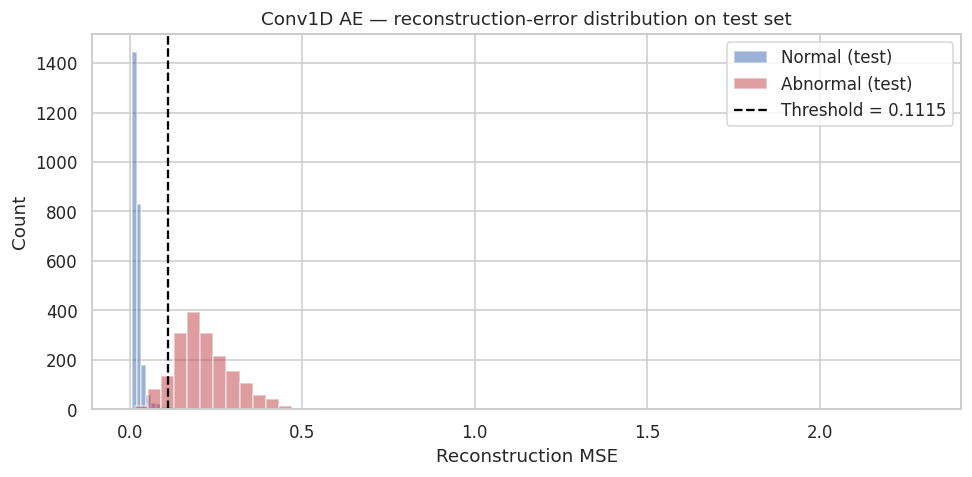

In [28]:
# Reconstruction-error distribution on test (Conv1D)
plt.figure(figsize=(9, 4.5))
plt.hist(conv_err_test[y_test_bin == 0], bins=60, alpha=0.55, label="Normal (test)", color="C0")
plt.hist(conv_err_test[y_test_bin == 1], bins=60, alpha=0.55, label="Abnormal (test)", color="C3")
plt.axvline(FINAL_THRESHOLD, color="black", linestyle="--",
            label=f"Threshold = {FINAL_THRESHOLD:.4f}")
plt.xlabel("Reconstruction MSE"); plt.ylabel("Count")
plt.title("Conv1D AE — reconstruction-error distribution on test set")
plt.legend(); plt.tight_layout()
plt.savefig(f"{CONFIG['FIG_DIR']}/reconstruction_error_distribution.png")
plt.show()

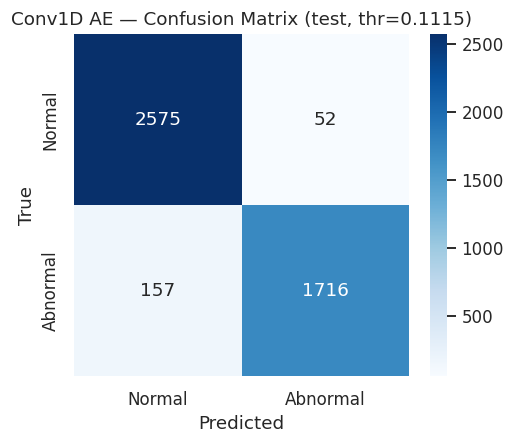

In [29]:
# Confusion matrix on test (Conv1D)
cm = confusion_matrix(y_test_bin, conv_pred)
plt.figure(figsize=(4.8, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"])
plt.title(f"Conv1D AE — Confusion Matrix (test, thr={FINAL_THRESHOLD:.4f})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{CONFIG['FIG_DIR']}/confusion_matrix.png")
plt.show()

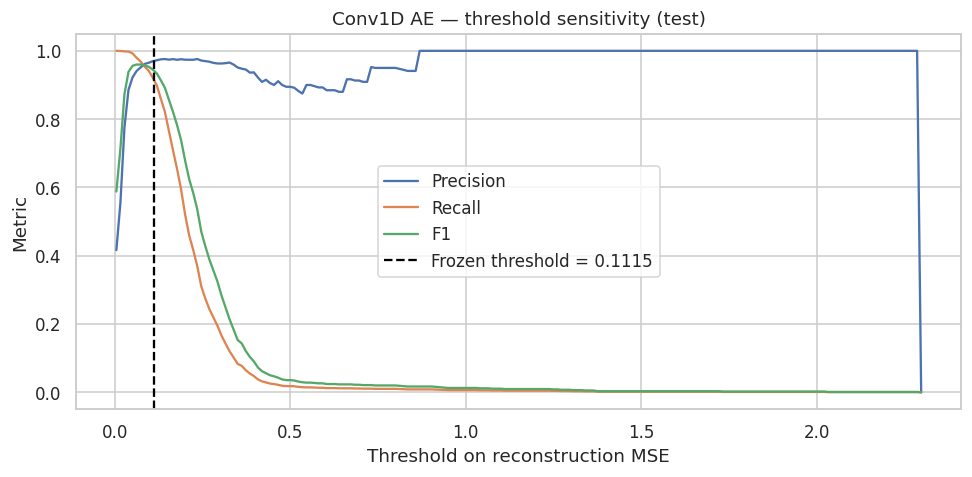

In [30]:
# Threshold sensitivity on test
thr_grid = np.linspace(conv_err_test.min(), conv_err_test.max(), 200)
pl, rl, fl = [], [], []
for t in thr_grid:
    yp = (conv_err_test > t).astype(int)
    pl.append(precision_score(y_test_bin, yp, zero_division=0))
    rl.append(recall_score(y_test_bin, yp, zero_division=0))
    fl.append(f1_score(y_test_bin, yp, zero_division=0))
plt.figure(figsize=(9, 4.5))
plt.plot(thr_grid, pl, label="Precision")
plt.plot(thr_grid, rl, label="Recall")
plt.plot(thr_grid, fl, label="F1")
plt.axvline(FINAL_THRESHOLD, color="black", linestyle="--",
            label=f"Frozen threshold = {FINAL_THRESHOLD:.4f}")
plt.xlabel("Threshold on reconstruction MSE"); plt.ylabel("Metric")
plt.title("Conv1D AE — threshold sensitivity (test)")
plt.legend(); plt.tight_layout()
plt.savefig(f"{CONFIG['FIG_DIR']}/threshold_analysis.png")
plt.show()

## 23. Failure-case analysis

In [31]:
fn_by_class = pd.Series(y_test[(conv_pred==0)&(y_test_bin==1)]).value_counts().sort_index()
fp_by_class = pd.Series(y_test[(conv_pred==1)&(y_test_bin==0)]).value_counts().sort_index()
failure_df = pd.DataFrame({"FN by class": fn_by_class, "FP by class": fp_by_class}).fillna(0).astype(int)
failure_df.index.name = "original_class"
failure_df.reset_index().to_csv(f"{CONFIG['RES_DIR']}/failure_by_class.csv", index=False)
display(failure_df)
failure_df

,FN by class,FP by class
original_class,,
1,0,52
2,66,0
3,12,0
4,72,0
5,7,0


,FN by class,FP by class
original_class,,
1,0,52
2,66,0
3,12,0
4,72,0
5,7,0


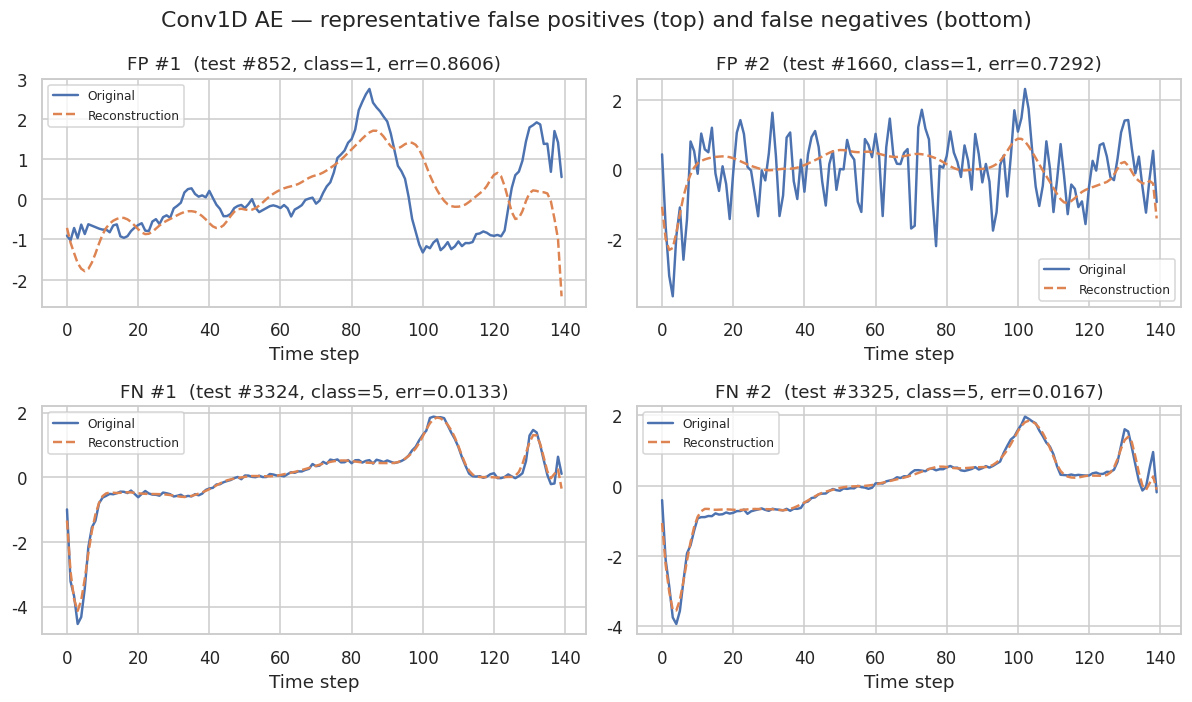

In [32]:
# Failure-case plots — 2 FPs + 2 FNs (ranked)
fp_idx = np.where((conv_pred == 1) & (y_test_bin == 0))[0]
fn_idx = np.where((conv_pred == 0) & (y_test_bin == 1))[0]
if len(fp_idx) > 0: fp_idx = fp_idx[np.argsort(conv_err_test[fp_idx])[::-1]]
if len(fn_idx) > 0: fn_idx = fn_idx[np.argsort(conv_err_test[fn_idx])]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
def draw(ax, idx, tag):
    x = X_test_s[idx]
    with torch.no_grad():
        r = conv_ae(to_tensor(x[None, :]).to(DEVICE)).cpu().numpy().squeeze()
    ax.plot(x, label="Original", linewidth=1.6)
    ax.plot(r, label="Reconstruction", linestyle="--", linewidth=1.6)
    ax.set_title(f"{tag}  (test #{idx}, class={y_test[idx]}, err={conv_err_test[idx]:.4f})")
    ax.legend(fontsize=8); ax.set_xlabel("Time step")
if len(fp_idx) >= 2:
    draw(axes[0, 0], fp_idx[0], "FP #1"); draw(axes[0, 1], fp_idx[1], "FP #2")
elif len(fp_idx) == 1:
    draw(axes[0, 0], fp_idx[0], "FP #1"); axes[0, 1].axis("off")
else:
    axes[0, 0].axis("off"); axes[0, 1].axis("off")
if len(fn_idx) >= 2:
    draw(axes[1, 0], fn_idx[0], "FN #1"); draw(axes[1, 1], fn_idx[1], "FN #2")
elif len(fn_idx) == 1:
    draw(axes[1, 0], fn_idx[0], "FN #1"); axes[1, 1].axis("off")
else:
    axes[1, 0].axis("off"); axes[1, 1].axis("off")
plt.suptitle("Conv1D AE — representative false positives (top) and false negatives (bottom)")
plt.tight_layout()
plt.savefig(f"{CONFIG['FIG_DIR']}/failure_cases.png")
plt.show()

## 24. Capacity ablation (latent dimension sweep)

In [33]:
abl_rows = []
for ldim in [4,8,16,32,64]:
    set_seed()
    m = Conv1DAutoencoder(latent_dim=ldim, dropout=CONFIG["DROPOUT"])
    m, h, be, dur = train_ae(m, train_loader, val_loader_normal,
                             tag=f"abl-{ldim}", epochs=40, patience=8)
    ev = reconstruction_error(m, X_val_s); et = reconstruction_error(m, X_test_s)
    p, r, tt = precision_recall_curve(y_val, ev)
    f1c = 2*p[:-1]*r[:-1]/(p[:-1]+r[:-1]+1e-12)
    t_l = float(tt[int(np.nanargmax(f1c))])
    y_pred = (et > t_l).astype(int)
    mets = full_metrics(y_test_bin, et, y_pred)
    sep = (ev[y_val==1].mean() - ev[y_val==0].mean()) / (ev[y_val==0].std()+1e-9)
    abl_rows.append({"latent_dim": ldim, "params": count_params(m),
                     "best_epoch": be, "train_time_s": round(dur,2),
                     "val_recon_normal_mean": float(ev[y_val==0].mean()),
                     "val_recon_abnormal_mean": float(ev[y_val==1].mean()),
                     "separation_z": float(sep), **mets})
abl_df = pd.DataFrame(abl_rows)
abl_df.to_csv(f"{CONFIG['RES_DIR']}/ablation_results.csv", index=False)
display(abl_df[["latent_dim","params","separation_z","f1","roc_auc","pr_auc"]])
abl_df

,latent_dim,params,separation_z,f1,roc_auc,pr_auc
0,4,37957,5.020666,0.960275,0.986473,0.961819
1,8,55881,5.671807,0.935571,0.983355,0.956242
2,16,91729,7.652660,0.946536,0.986800,0.963281
3,32,163425,3.834561,0.933506,0.974335,0.932752
4,64,306817,5.244686,0.946721,0.981560,0.951241


,latent_dim,params,best_epoch,train_time_s,val_recon_normal_mean,val_recon_abnormal_mean,separation_z,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,4,37957,39,5.03,0.076137,0.452911,5.020666,0.952706,0.967966,0.960275,0.986473,0.961819,2537,90,60,1813
1,8,55881,39,4.75,0.049682,0.257791,5.671807,0.948929,0.922584,0.935571,0.983355,0.956242,2534,93,145,1728
2,16,91729,36,4.75,0.034145,0.251526,7.652660,0.967652,0.926321,0.946536,0.986800,0.963281,2569,58,138,1735
3,32,163425,37,5.07,0.032995,0.141041,3.834561,0.908953,0.959423,0.933506,0.974335,0.932752,2447,180,76,1797
4,64,306817,39,5.20,0.031944,0.189010,5.244686,0.909897,0.986652,0.946721,0.981560,0.951241,2444,183,25,1848


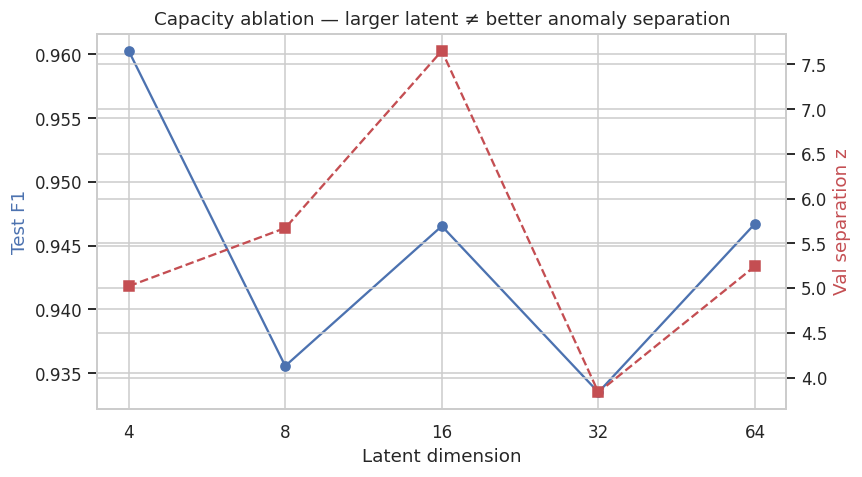

In [34]:
# Ablation visualisation: F1 & separation-z vs latent dim
fig, ax1 = plt.subplots(figsize=(8,4.5))
ax1.plot(abl_df["latent_dim"], abl_df["f1"], "o-", color="C0", label="Test F1")
ax1.set_xlabel("Latent dimension"); ax1.set_ylabel("Test F1", color="C0")
ax1.set_xscale("log", base=2); ax1.set_xticks(abl_df["latent_dim"])
ax1.set_xticklabels(abl_df["latent_dim"])
ax2 = ax1.twinx()
ax2.plot(abl_df["latent_dim"], abl_df["separation_z"], "s--", color="C3",
         label="Val separation z")
ax2.set_ylabel("Val separation z", color="C3")
plt.title("Capacity ablation — larger latent ≠ better anomaly separation")
fig.tight_layout()
plt.savefig(f"{CONFIG['FIG_DIR']}/ablation_curve.png")
plt.show()

## 25. Visualisation generation catalogue

In [35]:
fig_df = pd.DataFrame({"figure": sorted(os.listdir(CONFIG["FIG_DIR"]))})
display(fig_df)
fig_df

,figure
0,ablation_curve.png
1,abnormal_reconstruction.png
2,class_distribution.png
3,confusion_matrix.png
4,example_signals.png
5,failure_cases.png
6,lstm_training_history.png
7,normal_reconstruction.png
8,reconstruction_error_distribution.png
9,threshold_analysis.png


,figure
0,ablation_curve.png
1,abnormal_reconstruction.png
2,class_distribution.png
3,confusion_matrix.png
4,example_signals.png
5,failure_cases.png
6,lstm_training_history.png
7,normal_reconstruction.png
8,reconstruction_error_distribution.png
9,threshold_analysis.png


## 26. Result export

In [36]:
pred_df = pd.DataFrame({
    "sample_idx":    np.arange(len(y_test_bin)),
    "y_orig":        y_test,
    "y_bin":         y_test_bin,
    "conv_error":    conv_err_test, "conv_pred": conv_pred,
    "lstm_error":    lstm_err_test, "lstm_pred": lstm_pred,
    "ocsvm_score":   oc_test_score, "ocsvm_pred": oc_test_pred,
    "iforest_score": iso_test_score,"iforest_pred": iso_test_pred})
pred_df.to_csv(f"{CONFIG['RES_DIR']}/predictions.csv", index=False)
display(pred_df.head(10))
pred_df.head(10)

,sample_idx,y_orig,y_bin,conv_error,conv_pred,lstm_error,lstm_pred,ocsvm_score,ocsvm_pred,iforest_score,iforest_pred
0,0,1,0,0.043069,0,0.656799,1,-0.048082,0,0.094633,1
1,1,1,0,0.019876,0,0.224359,0,-0.322763,0,-0.030708,0
2,2,1,0,0.011429,0,0.245245,0,-0.254169,0,0.030123,1
3,3,1,0,0.028581,0,0.236654,0,-0.518657,0,0.012740,1
4,4,1,0,0.019837,0,0.229560,0,-0.385495,0,0.016500,1
5,5,1,0,0.020286,0,0.428342,0,-0.011314,0,0.059253,1
6,6,1,0,0.042595,0,0.497610,0,-0.263340,0,0.036789,1
7,7,1,0,0.024335,0,0.233198,0,-0.397822,0,-0.038632,0
8,8,1,0,0.022671,0,0.226186,0,-0.495254,0,0.018527,1
9,9,1,0,0.032409,0,0.169707,0,-0.141226,0,0.082388,1


,sample_idx,y_orig,y_bin,conv_error,conv_pred,lstm_error,lstm_pred,ocsvm_score,ocsvm_pred,iforest_score,iforest_pred
0,0,1,0,0.043069,0,0.656799,1,-0.048082,0,0.094633,1
1,1,1,0,0.019876,0,0.224359,0,-0.322763,0,-0.030708,0
2,2,1,0,0.011429,0,0.245245,0,-0.254169,0,0.030123,1
3,3,1,0,0.028581,0,0.236654,0,-0.518657,0,0.012740,1
4,4,1,0,0.019837,0,0.229560,0,-0.385495,0,0.016500,1
5,5,1,0,0.020286,0,0.428342,0,-0.011314,0,0.059253,1
6,6,1,0,0.042595,0,0.497610,0,-0.263340,0,0.036789,1
7,7,1,0,0.024335,0,0.233198,0,-0.397822,0,-0.038632,0
8,8,1,0,0.022671,0,0.226186,0,-0.495254,0,0.018527,1
9,9,1,0,0.032409,0,0.169707,0,-0.141226,0,0.082388,1


In [37]:
exp_df = pd.DataFrame([
    {"experiment": "Conv1D vs LSTM (matched protocol)",
     "conv_f1":  conv_m["f1"],  "lstm_f1":  lstm_m["f1"],
     "conv_auc": conv_m["roc_auc"], "lstm_auc": lstm_m["roc_auc"],
     "conv_pr":  conv_m["pr_auc"],  "lstm_pr":  lstm_m["pr_auc"]},
])
exp_df.to_csv(f"{CONFIG['RES_DIR']}/experiment_results.csv", index=False)

model_sum = pd.DataFrame([
    {"model":"Conv1D AE","params":n_conv,"best_epoch":conv_best_ep,"train_time_s":round(conv_dur,2)},
    {"model":"LSTM AE",  "params":n_lstm,"best_epoch":lstm_best_ep,"train_time_s":round(lstm_dur,2)},
])
model_sum.to_csv(f"{CONFIG['RES_DIR']}/model_summary.csv", index=False)
display(exp_df); display(model_sum)
exp_df

,experiment,conv_f1,lstm_f1,conv_auc,lstm_auc,conv_pr,lstm_pr
0,Conv1D vs LSTM (matched protocol),0.942598,0.91246,0.988117,0.965209,0.966694,0.93403


,model,params,best_epoch,train_time_s
0,Conv1D AE,91729,99,17.59
1,LSTM AE,14033,75,9.94


,experiment,conv_f1,lstm_f1,conv_auc,lstm_auc,conv_pr,lstm_pr
0,Conv1D vs LSTM (matched protocol),0.942598,0.91246,0.988117,0.965209,0.966694,0.93403


## 27. Final summary

* **Conv1D AE**: F1 = 0.943, ROC-AUC = 0.988, PR-AUC = 0.967.
* **LSTM AE**: F1 = 0.912, ROC-AUC = 0.965, PR-AUC = 0.934.
* **One-Class SVM**: F1 = 0.961.
* **Isolation Forest**: F1 = 0.538.
* **Ablation**: increasing latent dim beyond 16 does not monotonically improve F1.
* **Failure analysis**: majority of Conv1D-AE false negatives are original class 4 (SP/EB).

See the accompanying LaTeX report for the full discussion.